# Taller 3_Alina Elizondo Sánchez

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/heart_disease-UCI.csv', header=0,
                  names= ['edad','sexo','Dolor_toracico_Experimentado',
                  'Presion_Arterial_Reposo','Medicion_Colesterol',
                  'Glucemia_Ayunas','Medicion_Electrocardiografica',
                  'Frecuencia_Cardiaca_Maxima','Angina_Inducida',
                  'Pendiente_ST_Depresion', 'Pendiente_Pico_ST',
                  'Vasos_Sanguineos', 'Talasemia', 'Cardiopatia'])

df.tail()

Mounted at /content/drive


,edad,sexo,Dolor_toracico_Experimentado,Presion_Arterial_Reposo,Medicion_Colesterol,Glucemia_Ayunas,Medicion_Electrocardiografica,Frecuencia_Cardiaca_Maxima,Angina_Inducida,Pendiente_ST_Depresion,Pendiente_Pico_ST,Vasos_Sanguineos,Talasemia,Cardiopatia
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0



## Instrucciones

0- Preparación de los datos: Crear un diccionario de datos del dataset y convertir las variables que están en inglés en español.

1 – elijan tres combinaciones de tres de las variables, las que ustedes quieran (obviamente habrá variables que se repetirán)

2 – grafiquen los puntos, poniendo un color a los de la categoría con target **cardiopatía** y otro color a los de la categoría **no cardiopatía** **(20 puntos)**

3 – analicen cuan fácil o difícil es, así como el grado de errores que se cometerían, al tratar de separar ambas categorías. Pueden ustedes hacer al respecto un análisis cualitativo o incluso cuantitativo **(30 puntos)**

4 - ahora, lleven a cabo un proceso de reducción de dimensiones, basado en la técnica PCA, respondiendo a las siguientes cuestiones **(50 puntos)**

  4.1 - ¿cual es la función de varianza exhibida por cada una de las CP? Razone la respuesta

  4.2 - en función de los valores de los "loadings" ¿que conclusiones puede establecer sobre la varianza de las diferentes variables originales? Razone la respuesta

  4.3 - si usted reduce el conjunto de variables originales a un conjunto de 3 CP ¿cual es la diferencia con los ejemplos que constituyen sus respuestas al apartado 1 de este trabajo? FIJESE QUE NO SE PIDE COMPARAR RESULTADOS SINO diferencias entre la naturaleza de lo mostrado. Razone la respuesta

# 0 Preparación de los datos:
Crear un diccionario de datos del dataset y convertir las variables que están en inglés en español.

In [ ]:
print('Tipo de datos:\n')
print(df.dtypes)

Tipo de datos:

edad                               int64
sexo                               int64
Dolor_toracico_Experimentado       int64
Presion_Arterial_Reposo            int64
Medicion_Colesterol                int64
Glucemia_Ayunas                    int64
Medicion_Electrocardiografica      int64
Frecuencia_Cardiaca_Maxima         int64
Angina_Inducida                    int64
Pendiente_ST_Depresion           float64
Pendiente_Pico_ST                  int64
Vasos_Sanguineos                   int64
Talasemia                          int64
Cardiopatia                        int64
dtype: object


In [ ]:
diccionario = pd.DataFrame([
    {"Nombre de variable":"edad", "tipo_python":"int64",
     "descripcion": "Edad de la persona en años", ":tipo_estadistico":"cuantitativo"},

    {"Nombre de variable":"sexo", "tipo_python":"int64",
     "descripcion": "Sexo de la persona (1 = masculino, 0 = femenino)", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Dolor_toracico_Experimentado", "tipo_python":"int64",
     "descripcion": "Dolor torácico experimentado (Valor 1: angina típica, Valor 2: angina atípica, Valor 3: dolor no anginoso, Valor 4: asintomático)", ":tipo_estadistico":"cualitativo"},

     {"Nombre de variable":"Presion_Arterial_Reposo", "tipo_python":"int64",
     "descripcion": "Medición de colesterol de la persona en mg/dl", ":tipo_estadistico":"cuantitativo"},

    {"Nombre de variable":"Medicion_Colesterol", "tipo_python":"int64",
     "descripcion": "Medición de colesterol", ":tipo_estadistico":"cuantitativo"},

    {"Nombre de variable":"Glucemia_Ayunas", "tipo_python":"int64",
     "descripcion": " Glucemia en ayunas de la persona (>120 mg/dl, 1 = verdadero; 0 = falso)", ":tipo_estadistico:":"cuantitativo"},

    {"Nombre de variable":"Medicion_Electrocardiografica", "tipo_python":"int64",
     "descripcion": "Medición electrocardiográfica", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Frecuencia_Cardiaca_Maxima", "tipo_python":"int64",
     "descripcion": "Medición electrocardiográfica en reposo (0 = normal, 1 = con anomalía de la onda ST-T, 2 = con hipertrofia ventricular izquierda probable o definitiva según los criterios de Estes)", ":tipo_estadistico":"cuantitativo"},

    {"Nombre de variable":"Angina_Inducida", "tipo_python":"int64",
     "descripcion": "Angina inducida por el ejercicio (1 = sí; 0 = no)", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Pendiente_ST_Depresion", "tipo_python":"int64",
     "descripcion": "Depresión del segmento ST inducida por el ejercicio en relación con el reposo (el valor 'ST' se refiere a las posiciones en el gráfico del ECG.", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Pendiente_Pico_ST", "tipo_python":"float64",
     "descripcion": "Pendiente del segmento ST máximo durante el ejercicio (Valor 1: ascendente, Valor 2: plano, Valor 3: descendente)", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Vasos_Sanguineos", "tipo_python":"int64",
     "descripcion": "Número de vasos sanguíneos principales (0-3)", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Talasemia", "tipo_python":"int64",
     "descripcion": "Un trastorno sanguíneo llamado talasemia (3 = normal; 6 = defecto fijo; 7 = defecto reversible)", ":tipo_estadistico":"cualitativo"},

    {"Nombre de variable":"Cardiopatia", "tipo_python":"int64",
     "descripcion": "Cardiopatía (0 = no, 1 = sí)", ":tipo_estadistico":"cualitativo"}


        ])
print('\nDiccionario de datos:\n')

diccionario


Diccionario de datos:



,Nombre de variable,tipo_python,descripcion,:tipo_estadistico,:tipo_estadistico:
0,edad,int64,Edad de la persona en años,cuantitativo,NaN
1,sexo,int64,"Sexo de la persona (1 = masculino, 0 = femenino)",cualitativo,NaN
2,Dolor_toracico_Experimentado,int64,Dolor torácico experimentado (Valor 1: angina ...,cualitativo,NaN
3,Presion_Arterial_Reposo,int64,Medición de colesterol de la persona en mg/dl,cuantitativo,NaN
4,Medicion_Colesterol,int64,Medición de colesterol,cuantitativo,NaN
5,Glucemia_Ayunas,int64,"Glucemia en ayunas de la persona (>120 mg/dl,...",NaN,cuantitativo
6,Medicion_Electrocardiografica,int64,Medición electrocardiográfica,cualitativo,NaN
7,Frecuencia_Cardiaca_Maxima,int64,Medición electrocardiográfica en reposo (0 = n...,cuantitativo,NaN
8,Angina_Inducida,int64,Angina inducida por el ejercicio (1 = sí; 0 = no),cualitativo,NaN
9,Pendiente_ST_Depresion,int64,Depresión del segmento ST inducida por el ejer...,cualitativo,NaN


## 1/2.Combinaciones
Grafiquen los puntos, poniendo un color a los de la categoría con target cardiopatía y otro color a los de la categoría no cardiopatía (20 puntos)

### Primera combinación

In [ ]:
#Dataframe
combinacion_cardiopatia =  pd.DataFrame(dict(Presion = df['Presion_Arterial_Reposo'],
Colesterol = df['Medicion_Colesterol'],
Edad = df["edad"],
Cardiopatia = df['Cardiopatia'],
))


#Gráfico
grafico = px.scatter_3d(combinacion_cardiopatia, x= 'Presion', y='Colesterol', z='Edad', color= 'Cardiopatia',
                        title =  'Distribución de las variables  presión arterial de reposo, medición del colesterol y edad con relación a incidencia la cardiopatía')
grafico.show()

In [ ]:
#Calcular correlación
corr = combinacion_cardiopatia.corr()
corr

,Presion,Colesterol,Edad,Cardiopatia
Presion,1.000000,0.123174,0.279351,-0.144931
Colesterol,0.123174,1.000000,0.213678,-0.085239
Edad,0.279351,0.213678,1.000000,-0.225439
Cardiopatia,-0.144931,-0.085239,-0.225439,1.000000


**Interpretación:**
Los puntos amarillos se representan las personas que representan cardiopatías. Mientras que de color azul, se representan las que no presentan cardiopatías. No se represnta una separación clara.

Desde cierto ángulo, se encuentra un outliner, de una persona que representa cardiopatía, poseee un presión arterial de 115, un colesterol demasisado alto de 564 y edad 67. Donde el principal outliner se haya en el colesterol.


Por otro lado, se encuentra un outliner de una persona con 200 de presion, colesterol de 288, edad 50 años que no presenta cardipatía. Pero, según esos niveles es mejor valorar un chequeo.

La relación entre la presión con la cardiopatía es de -0.14 es una correlación negativa muy baja casi nula.

La relación entre el colesterol y la cardiopatía es de -0.09 es una correlación negativa muy baja casi nula.

La relación entre la edad y la cardiopatía es de -0.23, es una correlación negativa muy baja casi nula.

### Segunda combinación

In [ ]:
#Dataframe
combinacion_cardiopatia2 = pd.DataFrame(dict(Dolor = df['Dolor_toracico_Experimentado'],
Presion = df['Presion_Arterial_Reposo'],
ST_Depresion = df["Pendiente_ST_Depresion"],
Cardiopatia = df['Cardiopatia'],
))


#Gráfico
grafico = px.scatter_3d(combinacion_cardiopatia2,
x='Dolor',  y='Presion',  z='ST_Depresion', color='Cardiopatia', title = 'Distribución entre las variables dolor torácico, presión arterial, ST_Depresión con relación a la cardiopatía',
color_continuous_scale= ["green", "yellow"])
grafico.show()

In [ ]:
#Calcular correlación
corr = combinacion_cardiopatia2.corr()
corr

,Dolor,Presion,ST_Depresion,Cardiopatia
Dolor,1.000000,0.047608,-0.149230,0.433798
Presion,0.047608,1.000000,0.193216,-0.144931
ST_Depresion,-0.149230,0.193216,1.000000,-0.430696
Cardiopatia,0.433798,-0.144931,-0.430696,1.000000


**Interpretación**

Los puntos de color amarillo representan las personas con presencia de cardiopatías y en verde las que no tienen cardiopatías.

Los puntos de color amarillo se sitúan los niveles más altos de presión y ST_Depresión relacionandolos con la presencia de cardiopatías.

Se percibe una separación más o menos clara, en donde los puntos verdes (sin cardiopatías) se tienden a grupar más al lado izquierdo , es decir tienen valores más bajos. Mientras que del lado derecho se visualizan más los puntos amarillos asociados con cardiopatías, poseen los valores más altos con relación al dolor torácico, la presión arterial en reposo y depresión del segmento ST.

Ahora bien, tomando en cuenta la correlación, el dolor torácico se asocia con la cardipatía en un 0.43, lo cual indica una correlación positiva moderada. Es decir, entre más aumenta el dolor torácico, más aumenta el riesgo de presentar cardiopatía.


La presión se asocia con la cardipatía en un -0.14, indicando que es una correlación negativa muy baja. Es decir, la relación no es significativa.


Y la ST_Depresion se asocia con la cardiopatía en un -0.43, mostrando una relación negativa moderada. Es decir, conforme aumenta la presión del segmento ST, la probabilidad de cardiopatía disminuye. Cabe destacar que en la ciencia medica si guardan una relación positiva, donde si aumenta la depresión del segmento, aumenta la probabilidad de cardiopatía.

### Tercera combinación

In [ ]:
#Dataframe
combinacion_cardiopatia3 = pd.DataFrame(dict(Sexo = df['sexo'],
Edad = df['edad'],
Frecuencia = df["Frecuencia_Cardiaca_Maxima"],
Cardiopatia = df['Cardiopatia']
))


#Gráfico
grafico = px.scatter_3d(combinacion_cardiopatia3,
x="Sexo", y="Edad", z="Frecuencia", color="Cardiopatia",
title = 'Distribución entre las variables sexo, edad y frecuencia cardíaca con relación a la cardiopatía',
color_continuous_scale= ["green", "red"],
size="Sexo", size_max=18, symbol="Edad", opacity=0.7 )

# Márgenes
grafico.update_layout(margin=dict(l=0, r=0, b=0, t=0)
)

grafico.show()

In [ ]:
#Calcular correlación
corr = combinacion_cardiopatia3.corr()
corr

,Sexo,Edad,Frecuencia,Cardiopatia
Sexo,1.000000,-0.098447,-0.044020,-0.280937
Edad,-0.098447,1.000000,-0.398522,-0.225439
Frecuencia,-0.044020,-0.398522,1.000000,0.421741
Cardiopatia,-0.280937,-0.225439,0.421741,1.000000


**Interpretación:**
Los símbolos rojos hacen referencia a la presencia de cardiopatía y los verdes a la ausencia de cardiopatía.
Se puede decir que están bastante unidos a un sólo lado del gráfico. No obstante, parece que los símbolos rojos se encuentran más en la parte superior y los verdes en la parte inferior, lo cual permite percibir una cierta separación.

Entre los valores atípicos destaca un punto verde (sin cardiopatía), de un masculino, de 77 años de edad, con una frecuencia cardíaca de 162. Loc ual hay que analizar puesto que para su edad avanzada y su frecuencia cardíaca no presenta cardiopatía.
Asimismo, existe un punto de color rojo(cardiopatía), el cual es un masculino, de 29 años de edad con un afrecuencia cardíaca de 202. Es un caso a analizar, ya que se trata de una persona joven con un valor extremadamente alto en la frecuencia cardíaca y tiene presencia de cardiopatía.

Con respecto a las correlaciones, se encuentra que el sexo guarda una correlación de -0.28 con respecto a la cardiopatía. Esto indica que es una correlación negativa débil, donde ser hombre tiene menor probabilidad de cardiopatía. No obstante, hay que analizar la distribución y representitividad de la muestra.

Por otro lado, la edad correlacionada con la cardiopatía es de -0.22, lo cual sugiere que es una correlación negativa débil, donde la edad no sería tan relevante, aunque en la realidad es relevante, por lo que habría que analizar la muestra.

Y por último, la frecuencia cardiaca tiene una relación de 0.42 con relación a la cardiopatía. Es de cir, es una correlación positiva moderada, donde si la frecuencia cardiaca aumenta, la posibilidad de una cardiopatía se eleva.

## 3.Análisis de grados de errores
Analicen cuan fácil o difícil es, así como el grado de errores que se cometerían, al tratar de separar ambas categorías. Pueden ustedes hacer al respecto un análisis cualitativo o incluso cuantitativo **(30 puntos)**


In [ ]:
def confirmacion(valor, columnas, validacion):
    total = len(validacion)

    for indice, columna in enumerate(columnas):
        indice_may_no = 0
        indice_menor_no = 0

        for i in range(total):
# Mayores al corte y no cardiacos
            if columna[i] > valor:
                if validacion[i] == 0:
                    indice_may_no += 1

# Menores o iguales al corte y no cardiacos
            if columna[i] <= valor:
                if validacion[i] == 0:
                    indice_menor_no += 1

        print('\nColumna\n', indice + 1)
        print('\nCantidad de numeros mayores al corte y no cardiacos es:',indice_may_no)
        print('\n Error: ', (indice_may_no/total)*100)
        print('\nCantidad de numeros menores al corte y no cardiacos',indice_menor_no)
        print('\n Error: ', (indice_menor_no/total)*100)

        print('Total:', total)

# Punto de corte y llamada de variables
valor = 150
a= df['Presion_Arterial_Reposo']
b= df['Medicion_Colesterol']
c= df['edad']
v = df['Cardiopatia']
confirmacion(valor,[a, b,c], v)


Columna
 1

Cantidad de numeros mayores al corte y no cardiacos es: 21

 Error:  6.9306930693069315

Cantidad de numeros menores al corte y no cardiacos 117

 Error:  38.613861386138616
Total: 303

Columna
 2

Cantidad de numeros mayores al corte y no cardiacos es: 136

 Error:  44.884488448844884

Cantidad de numeros menores al corte y no cardiacos 2

 Error:  0.6600660066006601
Total: 303

Columna
 3

Cantidad de numeros mayores al corte y no cardiacos es: 0

 Error:  0.0

Cantidad de numeros menores al corte y no cardiacos 138

 Error:  45.54455445544555
Total: 303


**Interpretación**

Columna 1: Presión arterial en reposo
Mayores al corte: 21
Menores o iguales: 117
La mayoría de personas sin ausencia de cardiopatías, especificamente, 117 personas tienen una presión arterial igual o menor al punto de cohorte de 150. Mientras que 21 personas tienen una presión mayor a 150.
Por ende, la mayoría de personas sin poblemas cardiacos tiene una presión arterial de reposo menor a 150. También se deduce que al existen dos grupos por encima y por debajo del punto de cohorte se puede hacer una separación intermedia, ya que tiene buena distribución, hay datos de ambos lados.


Columna 2: Colesterol
Mayores al corte: 136
Menores:2
La mayoría de personas sin cardiopatías (136) presentan un nivel de colesterol por encima de 150. Mientras que solamente 2 personas presentan un nivel de colesterol por debajo del cohorte. Se puede hacer una separación, pero es muy débil, los grupos no son equilibrados.


Columna 3: Edad
Mayores: 0
Menores: 138
De las 138 personas nadie obviamente supera los 150 años de edad. La separación en nula.


En conclusión, la separación de estas variables es muy díficil. Con un cohorte de 150, algunas variables son nulas de separar (edad). Mientras, si el cohorte se reduce la edad se separaría, pero las otras dos variables (presión y colesterol) no se podrían separar. No hay cohorte que se adapte a las tres variables, ya que todas tienen distribuciones diferentes.


## 4.Proceso de reducción de dimensiones


###   4.1 - ¿Cuál es la función de varianza exhibida por cada una de las CP?

Razone la respuesta

Varianza por componente: [23.06 16.87 15.73 12.98 11.45 10.15  9.78]


Media de las variables estandarizadas [ 0. -0. -0.  0.  0.  0. -0.]

Desviación estándar de las variables estandarizadas [1.27 1.09 1.05 0.95 0.9  0.84 0.83]


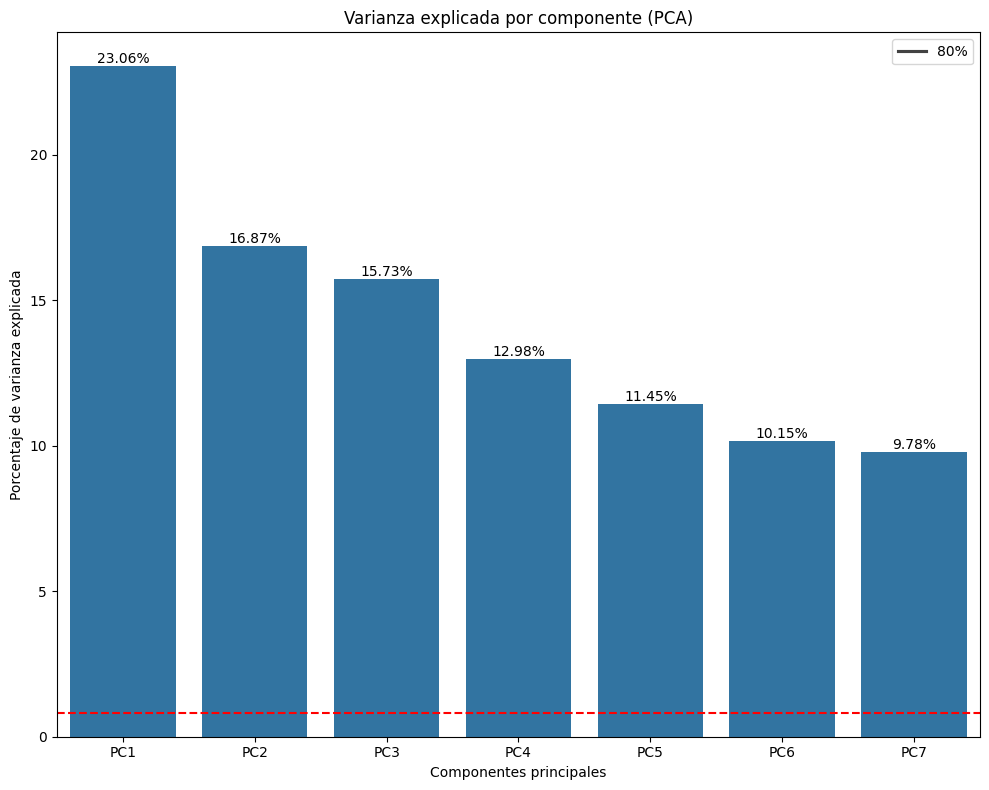

In [ ]:
# Importar librería
from sklearn.preprocessing import StandardScaler

#Definir las variables independientes y dependientes
x =  df.iloc[:,0:7]  # se toman las variables de x
y =  df.iloc[:,-1] # se toma la variable como la y

# Estandarizacion o normalizacion de las variables
x= StandardScaler().fit_transform(x)

# Aplicar PCA para saber el porcentaje de varianza de las componentes
pca = PCA(n_components=None)
componentes_principales =  pca.fit_transform(x)

#Calcular varianza por componente
Varianza = np.round(pca.explained_variance_ratio_* 100, decimals =2)
print ('Varianza por componente:', Varianza)
print('\n')

# Media de las variables estandarizadas
print('Media de las variables estandarizadas', componentes_principales.mean(axis=0).round(2))

# Desviación estándar de las variables estandarizadas
print('\nDesviación estándar de las variables estandarizadas', componentes_principales.std(axis=0).round(2))

#Grafico de barras
componentes= ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']

plt.figure(figsize=(10,8))
ax= sns.barplot(x= componentes, y= Varianza)
plt.ylabel('Porcentaje de varianza explicada')
plt.xlabel('Componentes principales')
ax.bar_label(ax.containers[0], fmt= '%.2f%%')
plt.title('Varianza explicada por componente (PCA)')
plt.xticks(range(0,7))
plt.axhline(y=0.8, color='red', linestyle='--')
plt.legend(['80%'])
plt.tight_layout()
plt.show()

**Interpretación**
En base al anterior análisis de componentes principales (PCA), se obtiene el porcentaje de varianza de cada componente, donde a partir del componente 5, se obtiene el 80% de la varianza. Es decir, con 5 componentes se puede reducir la dimensionalidad mantienen un análisis equilibrado sin perder información importante.


A media de cada componenete es cero, debido a la estandarización o normalización previa.

Por su parte la desviación estándar indica la dispersión de cada componente, en donde el componente PC1 tienen la desviaciónn estándar más grande con un 1.27, mientras que la desviacion estándar de PC7, obtiene la desviación estandar más baja con un 0.83.

###   4.2 - En función de los valores de los "loadings" ¿que conclusiones puede establecer sobre la varianza de las diferentes variables originales? Razone la respuesta

Cargas de las variables (autovectores)                                     PC1       PC2       PC3       PC4  \
edad                           0.695155 -0.042339 -0.039389  0.355417   
sexo                          -0.286908  0.511345 -0.618588  0.094252   
Dolor_toracico_Experimentado  -0.052377  0.452007  0.667629 -0.439679   
Presion_Arterial_Reposo        0.638029  0.286231  0.109271  0.264999   
Medicion_Colesterol            0.580042 -0.458791  0.003953 -0.277452   
Glucemia_Ayunas                0.362827  0.640012  0.070737  0.066364   
Medicion_Electrocardiografica -0.419243 -0.121878  0.507592  0.656611   

                                    PC5  
edad                          -0.168375  
sexo                          -0.167258  
Dolor_toracico_Experimentado  -0.265481  
Presion_Arterial_Reposo       -0.407826  
Medicion_Colesterol            0.214825  
Glucemia_Ayunas                0.670183  
Medicion_Electrocardiografica  0.125009  


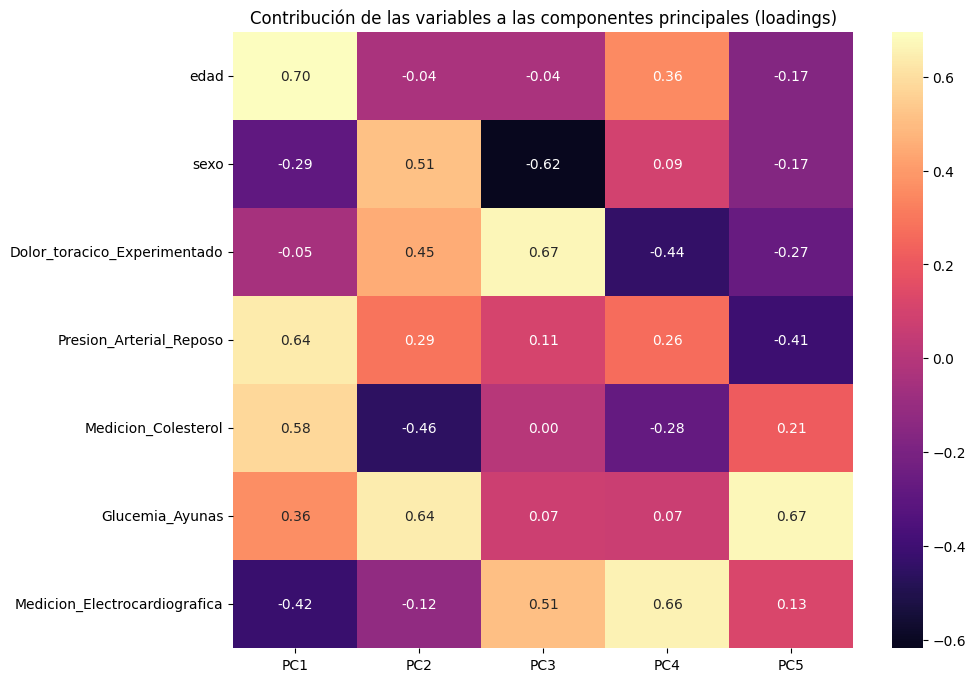

In [ ]:
# Analizar las cargas de los componentes
# Escalar las cargas
loading = pca.components_ * np.sqrt(pca.explained_variance_).reshape(-1, 1)

nombre_variables = df.columns[0:7]
df_loading = pd.DataFrame(loading.T[:, :5], columns= ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], index= nombre_variables)

print('Cargas de las variables (autovectores)',df_loading)

#Visualización de cargas por medio de mapa de calor
plt.figure(figsize=(10,8))
sns.heatmap(df_loading, cmap= 'magma', annot= True, center= 0, fmt= '.2f')
plt.title('Contribución de las variables a las componentes principales (loadings)')
plt.show()

**Interpretación**
En este gráfico de calor se puede apreciar los cinco componentes loading.

PC1: Las variables, más relevantes son la edad con un 0.70, la presión arterial con un 0.64 y el colesterol con un 0.58. Es decir, en el PC1, estás variables son las más asociadas con la cardiopatía.

PC2: La variable más relevante es la glucemia en ayunas y el sexo con relación a las cardiopatías.

PC3: Las variables más importantes son el dolor torácico y la medición electrocardiografica.

PC4: Las variables más importantes son la medición electrocardiográfica y la edad.

PC5: Las variables más fundamentales son la glucemia en ayunas y la preción arterial en reposo.


En general dos de las variables que influyen más son la edad en PC1, la glucemia en PC5 y el dolor torácico experimentado en PC3
Y la de menor influencia es la medición del colesterol en PC3



##   4.3 - Si usted reduce el conjunto de variables originales a un conjunto de 3 CP ¿cual es la diferencia con los ejemplos que constituyen sus respuestas al apartado 1 de este trabajo? FIJESE QUE NO SE PIDE COMPARAR RESULTADOS SINO diferencias entre la naturaleza de lo mostrado. Razone la respuesta

### Reducción de componentes

In [ ]:
#Reducir a 3 componentes y visualizar
pca = PCA(n_components=3)
principal_components =  pca.fit_transform(x)

#Creación de un dataframe con los componentes y el target
componentes_principales = pd.DataFrame(principal_components,columns= ['PCA1', 'PCA3', 'PCA5'])
target_cardiopatia = pd.DataFrame(y)

#Concatenar los componentes principales con el target de cardiopatia
componentes_principales = pd.concat([componentes_principales, target_cardiopatia], axis= 1)

# Mostrar los 5 datos luego de la concatenación
componentes_principales.head()

,PCA1,PCA3,PCA5,Cardiopatia
0,1.565737,2.932113,0.570743,1
1,-1.669982,0.409773,0.704535,1
2,-0.682061,-0.432307,0.413274,1
3,-0.894975,-0.110988,-0.050939,1
4,0.729334,-2.489576,0.602089,1


### Gráfico final

In [ ]:
# Dataframe para grafico final
com_final =  pd.DataFrame(dict(PCA1 = componentes_principales['PCA1'],
                          PCA3 =  componentes_principales['PCA3'],
                          PCA5 = componentes_principales['PCA5'],
                          Cardiopatia = componentes_principales['Cardiopatia']))

#Gráfico 3D
grafico_final = px.scatter_3d(com_final, x= 'PCA1', y='PCA3', z='PCA5', color= 'Cardiopatia', symbol= 'Cardiopatia',
                              color_continuous_scale= 'Viridis', opacity=0.8,
                              labels= {'PCA1': 'Edad', 'PCA3': 'Glucemia en Ayunas', 'PCA5': 'Dolor torácico experimentado'},
                              title= 'Distribución de los principales componentes que inciden en la cardiopatía según PCA')
grafico_final.update_traces(marker=dict(size=10, line=dict(width=2)))
grafico_final.show()

**Interpretación**

Con el análisis PCA, se permite encontrar las 3 variables con mayor peso con relación a la cardiiopatía. Mientras que al azar, como en el ejercicio uno se hace por convenienza.
De ahí, la importancia de PCA, que permite obtener información de los datos más precisos.

Tambíén existe más separación de los datos para un mejor análisis en la parte superior con los valores más altos de edad, glucemia y dolor torácico experimentado se encuentran las personas que presentan cardiopatías. Por su parte, en la parte bajo con niveles más bajos se encuentran las persona que no presentan cardiopatías.

## Referencias

Plotly. (s.f.) 3d scatter plots. https://plotly.com/python/3d-scatter-plots/



Suárez Benson M. (2025). Funciones matemáticas. [Material complementario]